# Backpropagation

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Backpropagation is the key algorithm that makes Neural Networks trainable. It works by applying the chain rule to each layer and updating the parameters of the layer depending on how much it influences the final result. Below we use a dataset that has some complex structure (not linearly separable) and use it to train a small neural network.

shape of x_mat_full is (500, 3)
shape of y is (500,)


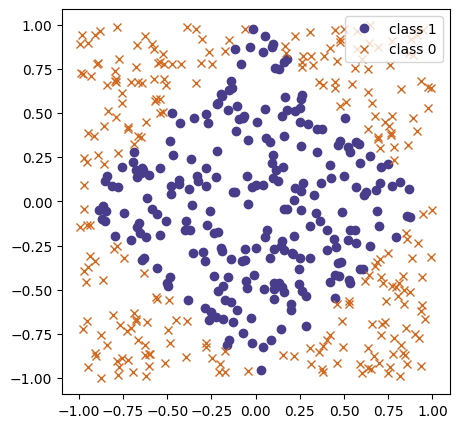

In [9]:
# Generate a number of uniformly distributed points in [-1, 1]^2, and include a bias term
num_obs = 500
x_mat_1 = np.random.uniform(-1,1,size = (num_obs,2))
x_mat_bias = np.ones((num_obs,1))
x_mat_full = np.concatenate( (x_mat_1,x_mat_bias), axis=1)

# PICK ONE PATTERN BELOW and comment out the rest.

# # Circle pattern
# y = (np.sqrt(x_mat_full[:,0]**2 + x_mat_full[:,1]**2)<.75).astype(int)

# # Diamond Pattern
y = ((np.abs(x_mat_full[:,0]) + np.abs(x_mat_full[:,1]))<1).astype(int)

# # Centered square
# y = ((np.maximum(np.abs(x_mat_full[:,0]), np.abs(x_mat_full[:,1])))<.5).astype(int)

# # Thick Right Angle pattern
# y = (((np.maximum((x_mat_full[:,0]), (x_mat_full[:,1])))<.5) & ((np.maximum((x_mat_full[:,0]), (x_mat_full[:,1])))>-.5)).astype(int)

# # Thin right angle pattern
# y = (((np.maximum((x_mat_full[:,0]), (x_mat_full[:,1])))<.5) & ((np.maximum((x_mat_full[:,0]), (x_mat_full[:,1])))>0)).astype(int)


print('shape of x_mat_full is {}'.format(x_mat_full.shape))
print('shape of y is {}'.format(y.shape))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x_mat_full[y==1, 0],x_mat_full[y==1, 1], 'o', label='class 1', color='darkslateblue')
ax.plot(x_mat_full[y==0, 0],x_mat_full[y==0, 1], 'x', label='class 0', color='chocolate')
# ax.grid(True)
ax.legend(loc='best')
ax.axis('equal');

Here we define some helper functions. First the sigmoid function which is used as an activation function for each layer. Then the loss function, which evaluates how far the prediction is from the true value. Then there is the forward pass, which implements the network. The network consists of an input layer, a single hidden layer and an output layer. The forward pass first runs the data through the network and checks its predictions. The gradient for each output pair is calculated and backpropagated through the network by calculating the partial derivatives with respect to each of the parameters. This function returns the gradients and the predicitons, which can now be used to update the weight matrices and plot the performance.

In [ ]:
def sigmoid(x):
    """
    Sigmoid function
    """
    return 1.0 / (1.0 + np.exp(-x))


def loss_fn(y_true, y_pred, eps=1e-16):
    """
    Loss function we would like to optimize (minimize)
    We are using Logarithmic Loss
    http://scikit-learn.org/stable/modules/model_evaluation.html#log-loss
    """
    y_pred = np.maximum(y_pred,eps)
    y_pred = np.minimum(y_pred,(1-eps))
    return -(np.sum(y_true * np.log(y_pred)) + np.sum((1-y_true)*np.log(1-y_pred)))/len(y_true)


def forward_pass(W1, W2):
    """
    Does a forward computation of the neural network
    Takes the input `x_mat` (global variable) and produces the output `y_pred`
    Also produces the gradient of the log loss function
    """
    global x_mat
    global y
    global num_
    # First, compute the new predictions `y_pred`
        # Hidden layer
    z_2 = np.dot(x_mat, W1)
    a_2 = sigmoid(z_2)
        # Output layer
    z_3 = np.dot(a_2, W2)
    y_pred = sigmoid(z_3).reshape((len(x_mat),))
    # Now compute the gradient
        # Distance between the prediction and the true label
    J_z_3_grad = -y + y_pred
        # Partial derivative of output layer
    J_W_2_grad = np.dot(J_z_3_grad, a_2)
        # Derivative of activation function
    a_2_z_2_grad = sigmoid(z_2)*(1-sigmoid(z_2))
        # Partial derivative of the hidden layer
    J_W_1_grad = (np.dot((J_z_3_grad).reshape(-1,1), W2.reshape(-1,1).T)*a_2_z_2_grad).T.dot(x_mat).T
    gradient = (J_W_1_grad, J_W_2_grad)
    
    return y_pred, gradient


def plot_loss_accuracy(loss_vals, accuracies):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle('Log Loss and Accuracy over iterations')
    
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(loss_vals)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Log Loss')
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(accuracies)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Accuracy');

The input of the network is a 3-element vector (x, y, bias). Which then feeds via a (3x4) matrix W_1 into a hidden layer of size 4. Finally, the (4x1) matrix W_2 represents the output layer, bringing the vector back to a single value, which is a value between 0 and 1 corresponding to which class the datapoint is classified as.

iteration 0, log loss is 0.7976, accuracy is 0.514
iteration 200, log loss is 0.6877, accuracy is 0.52
iteration 400, log loss is 0.6744, accuracy is 0.612
iteration 600, log loss is 0.6250, accuracy is 0.724
iteration 800, log loss is 0.5531, accuracy is 0.746
iteration 1000, log loss is 0.5230, accuracy is 0.756
iteration 1200, log loss is 0.5107, accuracy is 0.756
iteration 1400, log loss is 0.4723, accuracy is 0.778
iteration 1600, log loss is 0.3909, accuracy is 0.852
iteration 1800, log loss is 0.3348, accuracy is 0.888
iteration 2000, log loss is 0.2982, accuracy is 0.904
iteration 2200, log loss is 0.2682, accuracy is 0.92
iteration 2400, log loss is 0.2409, accuracy is 0.932
iteration 2600, log loss is 0.2193, accuracy is 0.942
iteration 2800, log loss is 0.2036, accuracy is 0.956
iteration 3000, log loss is 0.1922, accuracy is 0.956
iteration 3200, log loss is 0.1834, accuracy is 0.962
iteration 3400, log loss is 0.1764, accuracy is 0.96
iteration 3600, log loss is 0.1706, ac

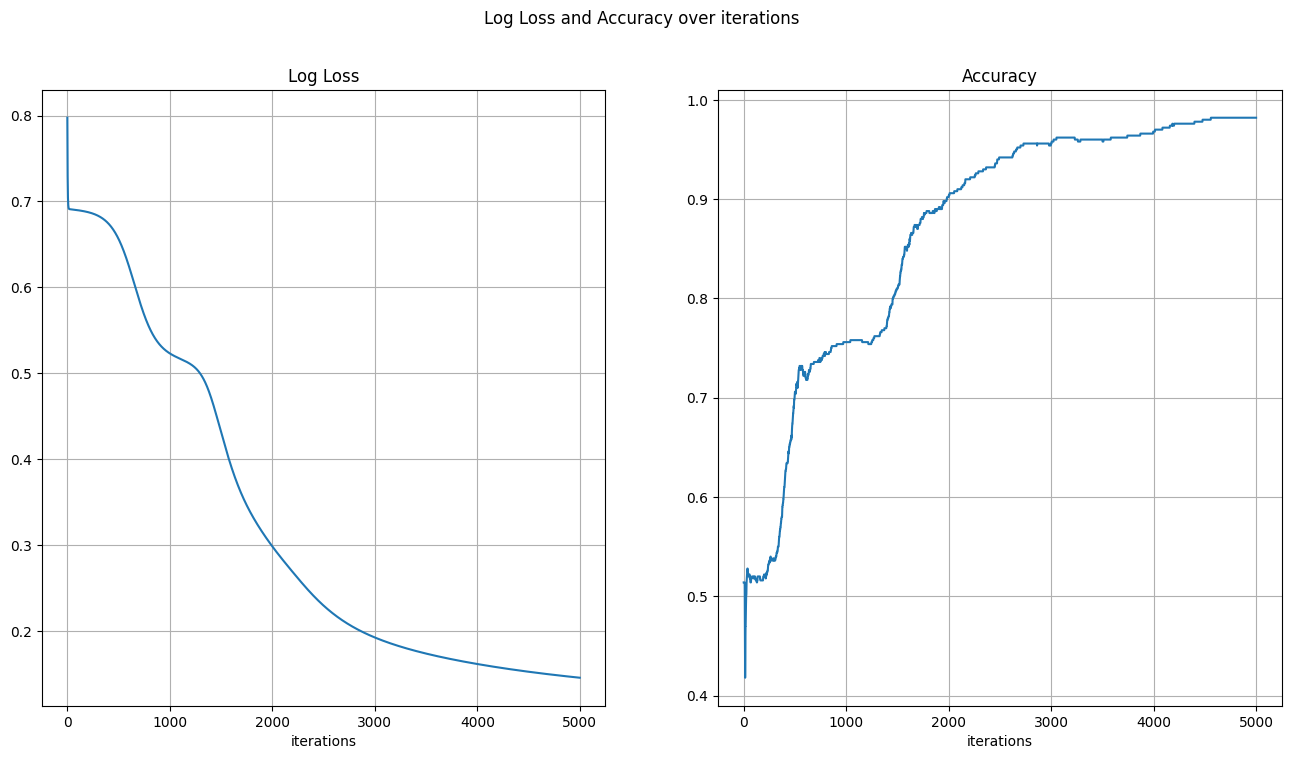

In [11]:
np.random.seed(1241)

W_1 = np.random.uniform(-1,1,size=(3,4))
W_2 = np.random.uniform(-1,1,size=(4))
num_iter = 5000
learning_rate = .001
x_mat = x_mat_full

loss_vals, accuracies = [], []
for i in range(num_iter):
    ### Do a forward computation, and get the gradient
    y_pred, (J_W_1_grad, J_W_2_grad) = forward_pass(W_1, W_2)
    
    ## Update the weight matrices
    W_1 = W_1 - learning_rate*J_W_1_grad 
    W_2 = W_2 - learning_rate*J_W_2_grad
    
    ### Compute the loss and accuracy
    curr_loss = loss_fn(y,y_pred)
    loss_vals.append(curr_loss)
    acc = np.sum((y_pred>=.5) == y)/num_obs
    accuracies.append(acc)

    ## Print the loss and accuracy for every 200th iteration
    if((i%200) == 0):
        print('iteration {}, log loss is {:.4f}, accuracy is {}'.format(
            i, curr_loss, acc
        ))
plot_loss_accuracy(loss_vals, accuracies)

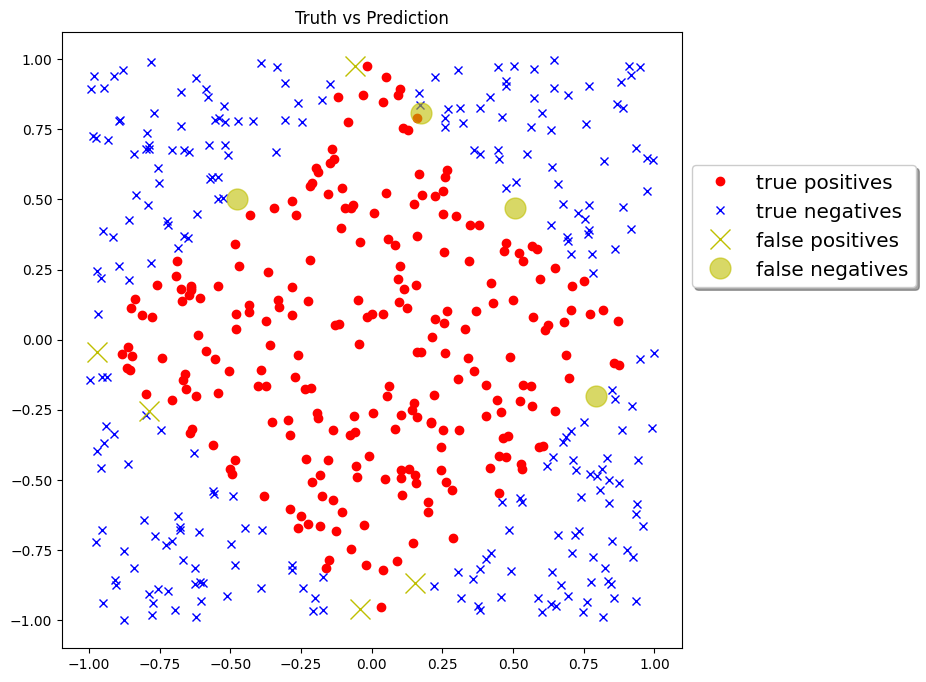

In [13]:
# Convert prediction to class labels
pred1 = (y_pred>=.5)
pred0 = (y_pred<.5)

fig, ax = plt.subplots(figsize=(8, 8))
# true predictions
ax.plot(x_mat[pred1 & (y==1),0],x_mat[pred1 & (y==1),1], 'ro', label='true positives')
ax.plot(x_mat[pred0 & (y==0),0],x_mat[pred0 & (y==0),1], 'bx', label='true negatives')
# false predictions
ax.plot(x_mat[pred1 & (y==0),0],x_mat[pred1 & (y==0),1], 'yx', label='false positives', markersize=15)
ax.plot(x_mat[pred0 & (y==1),0],x_mat[pred0 & (y==1),1], 'yo', label='false negatives', markersize=15, alpha=.6)
ax.set(title='Truth vs Prediction')
ax.legend(bbox_to_anchor=(1, 0.8), fancybox=True, shadow=True, fontsize='x-large');